# K-Nearest Neighbors (KNN) para Detecção de Alzheimer

## Objetivo
Este notebook implementa um **classificador KNN (K-Nearest Neighbors)** otimizado para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Sobre o KNN
O KNN é um algoritmo de aprendizado baseado em instâncias que classifica novos dados com base na "votação" dos K vizinhos mais próximos. É simples, intuitivo e não faz suposições sobre a distribuição dos dados.

### Características do KNN:
- **Lazy Learning**: Não há fase de treinamento explícita
- **Não-paramétrico**: Não faz suposições sobre a forma dos dados
- **Sensível à escala**: Requer normalização dos dados
- **Sensível ao valor de K**: K muito baixo = overfitting, K muito alto = underfitting

## Métricas Importantes para Diagnóstico Médico
- **Recall (Sensibilidade)**: Capacidade de identificar corretamente os casos positivos (doentes)
- **Precisão**: Proporção de diagnósticos positivos que são realmente corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC, mede a capacidade discriminativa do modelo

## 1. Importação das Bibliotecas

In [1]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Bibliotecas para Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier  # KNN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

# Biblioteca para balanceamento de dados
from imblearn.over_sampling import SMOTE

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Seed para reproducibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

import os

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Arquivo: {csv_path}')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Arquivo: C:/Users/pokab/Downloads/Codigos/Python/Redes Neurais/alzheimers_disease_data.csv
Dimensões: 2149 amostras x 35 features


In [3]:
# ==============================================================================
# EXPLORAÇÃO INICIAL DOS DADOS
# ==============================================================================

print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
display(df.describe())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. Pré-processamento dos Dados

In [4]:
# ==============================================================================
# PRÉ-PROCESSAMENTO DOS DADOS
# ==============================================================================

# Remoção de colunas irrelevantes
colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

# Verificação de valores nulos
print("\n" + "=" * 60)
print("VERIFICAÇÃO DE VALORES NULOS")
print("=" * 60)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("Não há valores nulos no dataset!")
else:
    print("Valores nulos por coluna:")
    print(nulos[nulos > 0])

# Verificação de duplicatas
print("\n" + "=" * 60)
print("VERIFICAÇÃO DE DUPLICATAS")
print("=" * 60)
duplicatas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicatas}")

if duplicatas > 0:
    df = df.drop_duplicates()
    print(f"Duplicatas removidas. Novas dimensões: {df.shape}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

VERIFICAÇÃO DE VALORES NULOS
Não há valores nulos no dataset!

VERIFICAÇÃO DE DUPLICATAS
Número de linhas duplicadas: 0


## 4. Análise da Variável Alvo

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)
  - Razão de desbalanceamento: 1.83:1


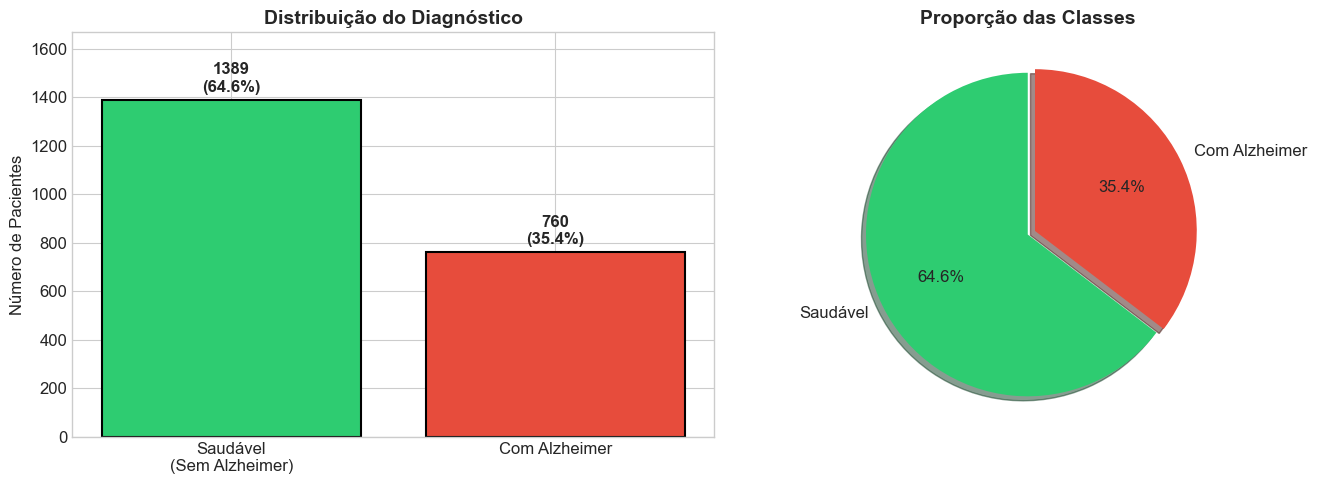

In [5]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO (Diagnosis)
# ==============================================================================

contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")
print(f"  - Razão de desbalanceamento: {contagem_classes[0]/contagem_classes[1]:.2f}:1")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Saudável\n(Sem Alzheimer)', 'Com Alzheimer'], 
                   [contagem_classes[0], contagem_classes[1]], 
                   color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, [contagem_classes[0], contagem_classes[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 f'{count}\n({count/len(df)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Distribuição do Diagnóstico', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Pacientes', fontsize=12)
axes[0].set_ylim(0, max(contagem_classes) * 1.2)

axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', 
            colors=colors,
            explode=(0, 0.05),
            shadow=True,
            startangle=90)
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('knn_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento e Preparação dos Dados

In [6]:
# ==============================================================================
# SEPARAÇÃO E BALANCEAMENTO DOS DADOS
# ==============================================================================

# Separando features e target
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Aplicando SMOTE
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\nApós o balanceamento (SMOTE):")
print(f"  - Classe 0 (Saudável): {sum(y_balanced == 0)}")
print(f"  - Classe 1 (Alzheimer): {sum(y_balanced == 1)}")
print(f"  - Total: {len(y_balanced)}")

Features (X): (2149, 32)
Target (y): (2149,)

Após o balanceamento (SMOTE):
  - Classe 0 (Saudável): 1389
  - Classe 1 (Alzheimer): 1389
  - Total: 2778


In [7]:
# ==============================================================================
# DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ==============================================================================

# Divisão estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, 
    y_balanced, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print("=" * 60)
print("DIVISÃO DOS DADOS")
print("=" * 60)
print(f"Conjunto de treino: {X_train.shape[0]} amostras")
print(f"Conjunto de teste: {X_test.shape[0]} amostras")

# Normalização (ESSENCIAL para KNN - baseado em distâncias)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalização aplicada com StandardScaler")
print("  IMPORTANTE: KNN é baseado em distâncias, normalização é CRUCIAL!")

DIVISÃO DOS DADOS
Conjunto de treino: 2083 amostras
Conjunto de teste: 695 amostras

Normalização aplicada com StandardScaler
  IMPORTANTE: KNN é baseado em distâncias, normalização é CRUCIAL!


## 6. Modelo KNN Base (Sem Otimização)

In [8]:
# ==============================================================================
# MODELO KNN BASE (HIPERPARÂMETROS PADRÃO)
# ==============================================================================

print("=" * 60)
print("TREINAMENTO DO MODELO KNN BASE")
print("=" * 60)

# Modelo com parâmetros padrão (k=5)
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)

# Predições
y_pred_base = knn_base.predict(X_test_scaled)
y_proba_base = knn_base.predict_proba(X_test_scaled)[:, 1]

# Métricas
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"\nResultados do Modelo Base (K=5):")
print(f"  Acurácia:  {acc_base*100:.2f}%")
print(f"  Precisão:  {prec_base*100:.2f}%")
print(f"  Recall:    {rec_base*100:.2f}%")
print(f"  F1-Score:  {f1_base*100:.2f}%")

TREINAMENTO DO MODELO KNN BASE

Resultados do Modelo Base (K=5):
  Acurácia:  71.37%
  Precisão:  65.95%
  Recall:    88.18%
  F1-Score:  75.46%


## 7. Encontrando o Melhor K (Otimização)

O valor de K é o hiperparâmetro mais importante do KNN:
- **K muito pequeno**: Modelo muito sensível a ruído (overfitting)
- **K muito grande**: Modelo muito generalista (underfitting)

BUSCANDO O MELHOR VALOR DE K

Melhor K (baseado no teste): 4
Acurácia com K=4: 76.12%


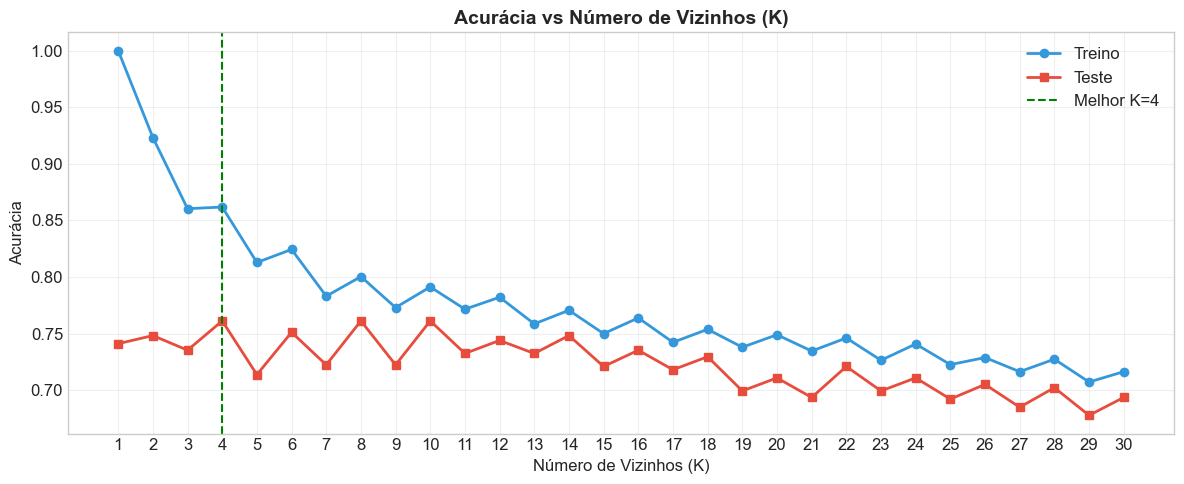

In [9]:
# ==============================================================================
# ENCONTRANDO O MELHOR VALOR DE K
# ==============================================================================

print("=" * 60)
print("BUSCANDO O MELHOR VALOR DE K")
print("=" * 60)

# Testando diferentes valores de K
k_range = range(1, 31)
scores_train = []
scores_test = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores_train.append(knn.score(X_train_scaled, y_train))
    scores_test.append(knn.score(X_test_scaled, y_test))

# Melhor K baseado no teste
best_k_simple = k_range[np.argmax(scores_test)]
print(f"\nMelhor K (baseado no teste): {best_k_simple}")
print(f"Acurácia com K={best_k_simple}: {max(scores_test)*100:.2f}%")

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(k_range, scores_train, 'o-', label='Treino', color='#3498db', linewidth=2)
plt.plot(k_range, scores_test, 's-', label='Teste', color='#e74c3c', linewidth=2)
plt.axvline(x=best_k_simple, color='green', linestyle='--', label=f'Melhor K={best_k_simple}')
plt.xlabel('Número de Vizinhos (K)', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Acurácia vs Número de Vizinhos (K)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('knn_melhor_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. GridSearch para Otimização Completa

In [10]:
# ==============================================================================
# GRIDSEARCH PARA OTIMIZAÇÃO COMPLETA
# ==============================================================================

print("=" * 60)
print("GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)

# Grade de hiperparâmetros
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],  # uniform: todos iguais, distance: mais próximos pesam mais
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1: Manhattan, p=2: Euclidean (só usado se metric='minkowski')
}

print("\nGrade de hiperparâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# GridSearch com validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='f1',  # Otimizando para F1-Score
    n_jobs=-1,
    verbose=1
)

print("\nExecutando GridSearch...")
grid_search.fit(X_train_scaled, y_train)

print(f"\n" + "=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_*100:.2f}%")

GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS

Grade de hiperparâmetros:
  n_neighbors: [3, 5, 7, 9, 11, 13, 15]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan', 'minkowski']
  p: [1, 2]

Executando GridSearch...
Fitting 5 folds for each of 84 candidates, totalling 420 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS:
  metric: manhattan
  n_neighbors: 7
  p: 1
  weights: distance

Melhor F1-Score (CV): 77.04%


## 9. Modelo Final Otimizado

In [11]:
# ==============================================================================
# MODELO FINAL OTIMIZADO
# ==============================================================================

print("=" * 60)
print("AVALIAÇÃO DO MODELO KNN OTIMIZADO")
print("=" * 60)

# Usando o melhor modelo encontrado
knn_otimizado = grid_search.best_estimator_

# Predições
y_pred = knn_otimizado.predict(X_test_scaled)
y_proba = knn_otimizado.predict_proba(X_test_scaled)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMétricas no Conjunto de Teste:")
print(f"  Acurácia:  {accuracy*100:.2f}%")
print(f"  Precisão:  {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")

# Relatório de classificação completo
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Alzheimer']))

AVALIAÇÃO DO MODELO KNN OTIMIZADO

Métricas no Conjunto de Teste:
  Acurácia:  71.37%
  Precisão:  64.86%
  Recall:    93.08%
  F1-Score:  76.45%

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

    Saudável       0.88      0.50      0.63       348
   Alzheimer       0.65      0.93      0.76       347

    accuracy                           0.71       695
   macro avg       0.76      0.71      0.70       695
weighted avg       0.76      0.71      0.70       695



## 10. Comparação: Modelo Base vs Otimizado

COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO

Métrica         Base (K=5)           Otimizado            Melhoria       
----------------------------------------------------------------------
Acurácia                    71.37%             71.37%        +0.00%
Precisão                    65.95%             64.86%        -1.09%
Recall                      88.18%             93.08%        +4.90%
F1-Score                    75.46%             76.45%        +0.99%


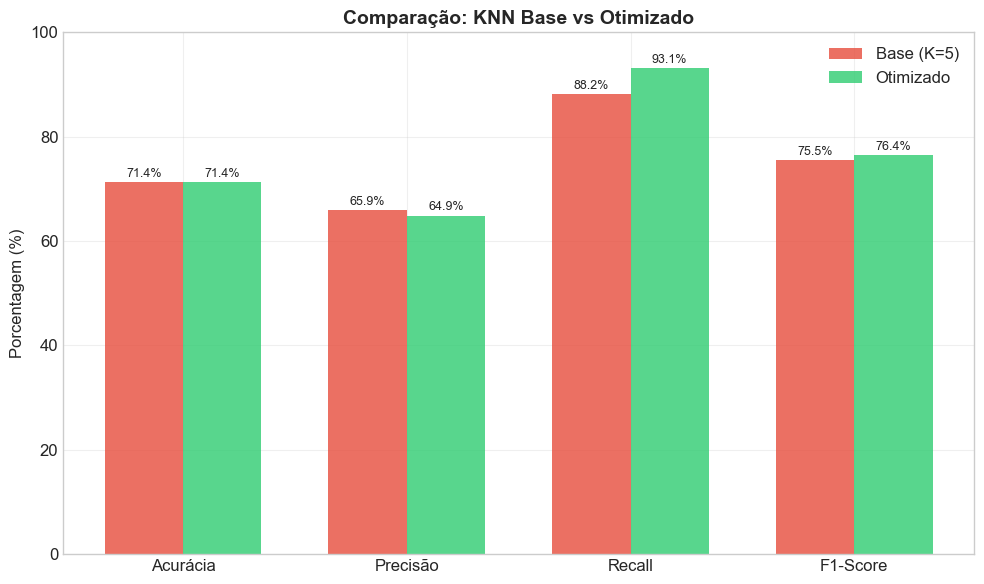

In [12]:
# ==============================================================================
# COMPARAÇÃO: BASE vs OTIMIZADO
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO")
print("=" * 70)

print(f"\n{'Métrica':<15} {'Base (K=5)':<20} {'Otimizado':<20} {'Melhoria':<15}")
print("-" * 70)
print(f"{'Acurácia':<15} {acc_base*100:>17.2f}% {accuracy*100:>17.2f}% {(accuracy-acc_base)*100:>+12.2f}%")
print(f"{'Precisão':<15} {prec_base*100:>17.2f}% {precision*100:>17.2f}% {(precision-prec_base)*100:>+12.2f}%")
print(f"{'Recall':<15} {rec_base*100:>17.2f}% {recall*100:>17.2f}% {(recall-rec_base)*100:>+12.2f}%")
print(f"{'F1-Score':<15} {f1_base*100:>17.2f}% {f1*100:>17.2f}% {(f1-f1_base)*100:>+12.2f}%")

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_base = [acc_base*100, prec_base*100, rec_base*100, f1_base*100]
valores_otim = [accuracy*100, precision*100, recall*100, f1*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, valores_base, width, label='Base (K=5)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valores_otim, width, label='Otimizado', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação: KNN Base vs Otimizado', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

for bar, val in zip(bars1, valores_base):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, valores_otim):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('knn_comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualizações Finais

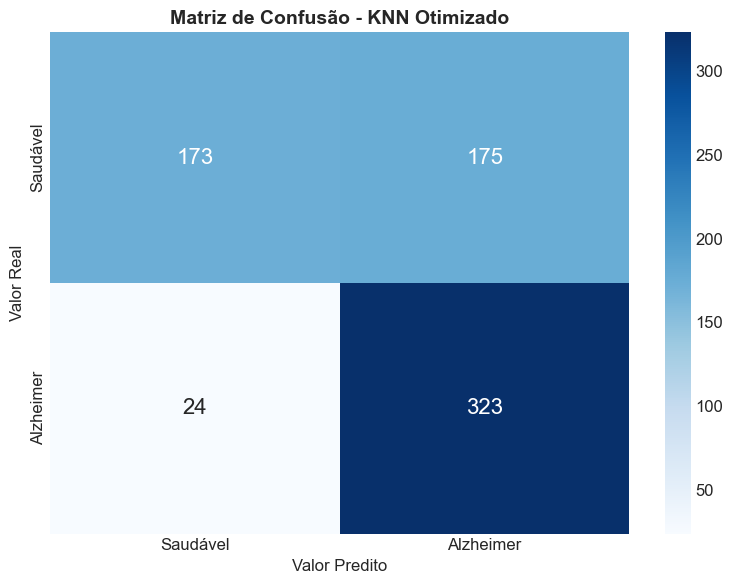


Análise da Matriz de Confusão:
  Verdadeiros Negativos (TN): 173
  Verdadeiros Positivos (TP): 323
  Falsos Positivos (FP): 175
  Falsos Negativos (FN): 24 <- Casos de Alzheimer não detectados


In [13]:
# ==============================================================================
# MATRIZ DE CONFUSÃO
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
plt.title('Matriz de Confusão - KNN Otimizado', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predito', fontsize=12)
plt.tight_layout()
plt.savefig('knn_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise detalhada
tn, fp, fn, tp = cm.ravel()
print(f"\nAnálise da Matriz de Confusão:")
print(f"  Verdadeiros Negativos (TN): {tn}")
print(f"  Verdadeiros Positivos (TP): {tp}")
print(f"  Falsos Positivos (FP): {fp}")
print(f"  Falsos Negativos (FN): {fn} <- Casos de Alzheimer não detectados")

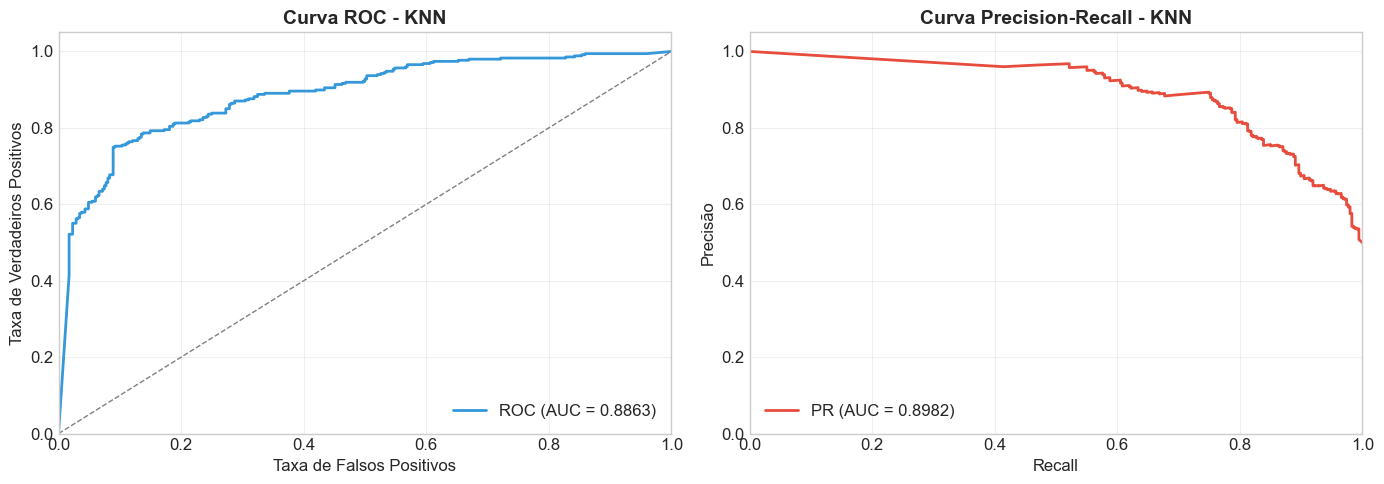


Área sob a curva ROC (AUC-ROC): 0.8863
Área sob a curva PR (AUC-PR): 0.8982


In [14]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC - KNN', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall - KNN', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nÁrea sob a curva ROC (AUC-ROC): {roc_auc:.4f}")
print(f"Área sob a curva PR (AUC-PR): {pr_auc:.4f}")

## 12. Conclusão

In [15]:
# ==============================================================================
# RESUMO FINAL
# ==============================================================================

print("=" * 70)
print("RESUMO FINAL - KNN PARA DETECÇÃO DE ALZHEIMER")
print("=" * 70)

print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nDesempenho Final:")
print(f"  - Acurácia:  {accuracy*100:.2f}%")
print(f"  - Precisão:  {precision*100:.2f}%")
print(f"  - Recall:    {recall*100:.2f}%")
print(f"  - F1-Score:  {f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.4f}")

print(f"\nAnálise de Erros:")
print(f"  - Falsos Negativos: {fn} (pacientes com Alzheimer não detectados)")
print(f"  - Falsos Positivos: {fp} (pacientes saudáveis diagnosticados erroneamente)")

print("\n" + "=" * 70)
print("VANTAGENS DO KNN PARA ESTE PROBLEMA:")
print("=" * 70)
print("""
  1. SIMPLICIDADE: Algoritmo intuitivo e fácil de interpretar
  2. SEM TREINAMENTO: Não requer fase de treinamento (lazy learning)
  3. NÃO-PARAMÉTRICO: Não faz suposições sobre a distribuição dos dados
  4. FLEXÍVEL: Funciona bem com diferentes tipos de dados
""")

print("LIMITAÇÕES:")
print("""
  1. LENTO PARA PREDIÇÃO: Precisa calcular distâncias para todos os pontos
  2. SENSÍVEL À ESCALA: Requer normalização obrigatória
  3. MALDIÇÃO DA DIMENSIONALIDADE: Performance degrada com muitas features
  4. SENSÍVEL A OUTLIERS: Pode ser afetado por pontos atípicos
""")

RESUMO FINAL - KNN PARA DETECÇÃO DE ALZHEIMER

Melhores Hiperparâmetros:
  - metric: manhattan
  - n_neighbors: 7
  - p: 1
  - weights: distance

Desempenho Final:
  - Acurácia:  71.37%
  - Precisão:  64.86%
  - Recall:    93.08%
  - F1-Score:  76.45%
  - AUC-ROC:   0.8863

Análise de Erros:
  - Falsos Negativos: 24 (pacientes com Alzheimer não detectados)
  - Falsos Positivos: 175 (pacientes saudáveis diagnosticados erroneamente)

VANTAGENS DO KNN PARA ESTE PROBLEMA:

  1. SIMPLICIDADE: Algoritmo intuitivo e fácil de interpretar
  2. SEM TREINAMENTO: Não requer fase de treinamento (lazy learning)
  3. NÃO-PARAMÉTRICO: Não faz suposições sobre a distribuição dos dados
  4. FLEXÍVEL: Funciona bem com diferentes tipos de dados

LIMITAÇÕES:

  1. LENTO PARA PREDIÇÃO: Precisa calcular distâncias para todos os pontos
  2. SENSÍVEL À ESCALA: Requer normalização obrigatória
  3. MALDIÇÃO DA DIMENSIONALIDADE: Performance degrada com muitas features
  4. SENSÍVEL A OUTLIERS: Pode ser afetado po